In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
#24-07-2026 - 27-07-2026
raw_data=pd.read_excel(r'C:\Users\jlhb1\OneDrive\Documentos\Zonar_projects\data\cea\EIN621_2.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2801 entries, 0 to 2800
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2801 non-null   str  
 1   Message  2801 non-null   str  
 2   Status   2801 non-null   str  
dtypes: str(3)
memory usage: 65.8 KB


In [15]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    2714
0x252514      85
0x252501       1
0x252511       1
Name: count, dtype: int64

In [16]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2801 entries, 0 to 2800
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2801 non-null   str  
 1   Message  2801 non-null   str  
 2   Status   2801 non-null   str  
 3   Headers  2801 non-null   str  
dtypes: str(4)
memory usage: 87.7 KB


Odometer

In [17]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 2799 entries, 0 to 2800
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             2799 non-null   str  
 1   Message             2799 non-null   str  
 2   Status              2799 non-null   str  
 3   Headers             2799 non-null   str  
 4   Odometer in meters  2799 non-null   int64
 5   Date                2799 non-null   str  
 6   Raw data            2799 non-null   str  
dtypes: int64(1), str(6)
memory usage: 174.9 KB
None


260724000738 -> 0 -> 12570575.0 -> 0x25251400590CD10869487064492787003C38402D000000644D00000007000061000000FFFFFFFFFFFFFFFFFFFF16D500BFCFCF8926072400073833D3BF44EA3397C239F8C740000000EF03871248FFFFFF00001C0000FFFFFF
260724000839 -> 1 -> 12570575.0 -> 0x252513005992660869487064492787003C38402D0000003A4600000007000061000000FFFFFFFFFFFFFFFFFFFF00D500BFCFCF8926072400083933D3BF44EA3397C239F8C740000000EF03871425FFFFFF00001C0001FFFFFF
260724000939 -> 2 -> 12570575.0 -> 0x252513005992670869487064492787003C38402D0000003E4500000007000061000000FFFFFFFFFFFFFFFFFFFF00D500BFCFCF8026072400093933D3BF44EA3397C239F8C740000000EF03841427FFFFFF00001C0002FFFFFF
260724000950 -> 3 -> 12570575.0 -> 0x25251400590CD20869487064492787003C38402D0000003E4600000007000020000000FFFFFFFFFFFFFFFFFFFF17D500BFCFCF7326072400095033D3BF44EA3397C239F8C740000000EF03821407FFFFFF00001F0001FFFFFF
260724000952 -> 4 -> 12570575.0 -> 0x25251400590CD30869487064492787003C38402D0000003E4700000007000061000000FFFFFFFFFFFFFFFFFFFF16D500BFC

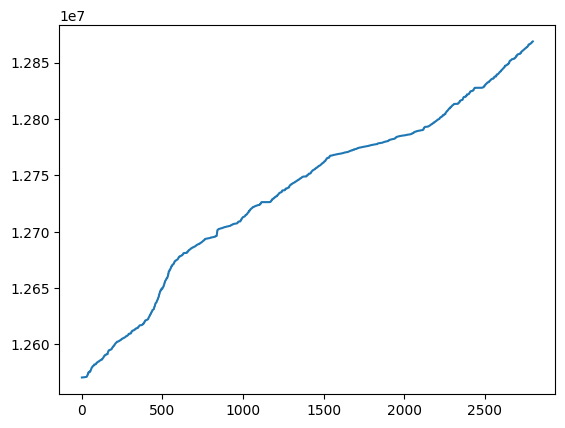

In [18]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [19]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 2799 entries, 2714 to 2713
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     2799 non-null   int64
 1   Date      2799 non-null   str  
 2   Raw data  2799 non-null   str  
dtypes: int64(1), str(2)
memory usage: 87.5 KB
None


260725014329 -> 820 -> 81.0 -> 0x252513005995760869487064492787003C38402D000000444600000007000020000000FFFFFFFFFFFFFFFFFFFF00D500C1B6F39226072501432933A3C444063497C2A7FDC7400810012603881268FFFFFF00002A0003FFFFFF
260725022208 -> 837 -> 97.0 -> 0x252513005995870869487064492787003C38402D0000003E4500000007000020000000FFFFFFFFFFFFFFFFFFFF00D500C1BC9B922607250222086646C0443F3297C2BCDCC7400970013D03881270FFFFFF0000260008FFFFFF
260725051751 -> 873 -> 125.0 -> 0x252513005995AB0869487064492787003C38402D0000003A4500000007000020000000FFFFFFFFFFFFFFFFFFFF00D500C1D608902607250517510000BC44D33397C26CECC7401250009903871261FFFFFF0000210005FFFFFF
260726093309 -> 1792 -> 91.0 -> 0x252513005999290869487064492787003C38402D000000374700000007000020000000FFFFFFFFFFFFFFFFFFFF00D500C2F4CA892607260933093373C544113497C26D03C8400910016003871243FFFFFF00001E0006FFFFFF


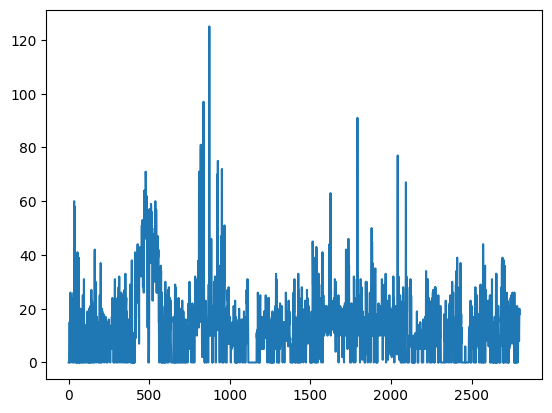

In [20]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #if (float(unit.iloc[i,0]))>100:
    #    print(raw_data_[i])
    
for i in range(0,len(speed)):
    if (y_axis[i]>80):
        print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])
        
plt.plot(x_axis,y_axis)

Satellites

In [21]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 2799 entries, 0 to 2800
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         2799 non-null   str  
 1   Message                         2799 non-null   str  
 2   Status                          2799 non-null   str  
 3   Headers                         2799 non-null   str  
 4   Satellites                      2799 non-null   int64
 5   Satellite_connection_indicator  2799 non-null   int64
 6   Raw data                        2799 non-null   str  
 7   date                            2799 non-null   str  
dtypes: int64(2), str(6)
memory usage: 196.8 KB
Eventos históricos:  0


In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [22]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 2799 entries, 1 to 2715
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2799 non-null   str  
 1   Message  2799 non-null   str  
 2   Status   2799 non-null   str  
 3   Headers  2799 non-null   str  
dtypes: str(4)
memory usage: 109.3 KB


Power

In [23]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 2799 entries, 1 to 2715
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2799 non-null   str  
 1   Message  2799 non-null   str  
 2   Status   2799 non-null   str  
 3   Headers  2799 non-null   str  
dtypes: str(4)
memory usage: 109.3 KB
Empty DataFrame
Columns: []
Index: []


Pánico

In [24]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 2799 entries, 1 to 2715
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2799 non-null   str  
 1   Message  2799 non-null   str  
 2   Status   2799 non-null   str  
 3   Headers  2799 non-null   str  
dtypes: str(4)
memory usage: 109.3 KB
len aux_cad:  2799
